# Vopalensky Test 16 - Real Reads Analysis
## Blind test: mixture of reads from 3 different caps (1:1:1 ratio)
## Using updated predict_cap.py with exclude_zero_caps fix
##
## Workflow:
## 1. Load TRAINING data (FM179-FM181 with known caps)
## 2. Generate synthetic mixtures from training data (or load saved model)
## 3. Load TEST data (Vopalensky - unknown cap composition)
## 4. Predict cap composition of test sample

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from rnacappredictor.predict_cap import (
    generate_fingerprint_mixes,
    predict_cap,
    predict_cap_with_saved_model,
    create_features,
    save_knn_model,
    load_knn_model,
    mix_fingerprints
)

## Configuration
### Set paths and model parameters

In [2]:
# Configuration
TRAINING_DATA_PATH = "../data/FM179-FM181_fingerprints.csv"
TEST_DATA_PATH = "../data/VP/U1-1_13/fingerprints.csv"
MODEL_SAVE_PATH = "../models/knn_model_Vopalensky_test16.pkl"
FIGURES_PATH = "../figures/"

# Create directories if they don't exist
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

print(f"Model path: {MODEL_SAVE_PATH}")
print(f"Model exists: {os.path.exists(MODEL_SAVE_PATH)}")

Model path: ../models/knn_model_Vopalensky_test16.pkl
Model exists: False


## Step 1: Load TRAINING data (FM179-FM181 with known cap types)

In [3]:
# Load TRAINING data - this has pure cap fingerprints with known 'cap' column
df_train = pd.read_csv(TRAINING_DATA_PATH)

print("Training data loaded:")
print(df_train.head())
print(f"\nShape: {df_train.shape}")
print(f"\nCaps in training data:")
print(df_train['cap'].value_counts())
print(f"\nRTs in training data:")
print(df_train['RT'].unique())

Training data loaded:
     barcode      isoform  num_reads  num_A  num_C  num_G  num_T  num_DEL  \
0  barcode02  E_(5_6_7_8)      17157   6617    820   1833   3059     2068   
1  barcode06  E_(5_6_7_8)      18227   8620    903    586   6890      567   
2  barcode10  E_(5_6_7_8)      22001   7932    831   1314   9330      810   
3  barcode14  E_(5_6_7_8)      20662   3248    902    497  13492     1223   
4  barcode18  E_(5_6_7_8)      20681   9262   1114    790   7201      351   

   num_INS  num_reads_ACGT  ...  INS%_INSDEL  DEL%_INSDEL        A%        C%  \
0     2760           12329  ...     0.160867     0.120534  0.536702  0.066510   
1      661           16999  ...     0.036265     0.031108  0.507089  0.053121   
2     1784           19407  ...     0.081087     0.036817  0.408719  0.042820   
3     1300           18139  ...     0.062917     0.059191  0.179062  0.049727   
4     1963           18367  ...     0.094918     0.016972  0.504274  0.060652   

         G%        T%  barco

## Step 2: Generate synthetic training mixtures OR load saved model
### SMART STEP: Skip training if model already exists!
### First time: Generates synthetic mixtures and saves model
### Subsequent times: Loads the saved model (much faster!)

In [4]:
# Define which caps to include in the model
cap_order = sorted(df_train['cap'].unique())

print(f"Caps available in training data: {cap_order}")
print(f"\nCap counts:")
print(df_train['cap'].value_counts())

# Check if model has already been trained and saved
if os.path.exists(MODEL_SAVE_PATH):
    print(f"\n" + "="*70)
    print(f"✓ FOUND EXISTING MODEL: {MODEL_SAVE_PATH}")
    print(f"="*70)
    print(f"\nSkipping training! Loading pre-trained model...")
    print(f"(If you want to retrain, delete the model file and rerun this cell)")
    
    # Load the existing model
    model = load_knn_model(MODEL_SAVE_PATH)
    
    # Also need to generate/load training mixtures for feature extraction
    # We'll generate them fresh since they're not too slow
    print(f"\nGenerating training mixtures for feature extraction...")
    df_train_mixes = generate_fingerprint_mixes(
        df_train,
        step_size=0.02,
        include_insdel=False,
        cap_order=cap_order,
        replicates_per_cap=5,
        exclude_zero_caps=True
    )
    print(f"✓ Training mixtures ready: {df_train_mixes.shape[0]} synthetic mixtures")
    
else:
    print(f"\n" + "="*70)
    print(f"NO EXISTING MODEL FOUND")
    print(f"="*70)
    print(f"\nThis is the FIRST TIME running this analysis.")
    print(f"Generating synthetic training mixtures...")
    print(f"(This may take a minute or two, maybe three... hours)\n")
    
    # Generate training mixtures with the FIX
    # exclude_zero_caps=True means all caps must be represented in some proportion
    # This prevents the "catch-all" bias where one cap receives inflated predictions
    try:
        df_train_mixes = generate_fingerprint_mixes(
            df_train,
            step_size=0.02,
            include_insdel=False,
            cap_order=cap_order,
            replicates_per_cap=5,
            exclude_zero_caps=True  # ← THIS IS THE FIX for catch-all bias!
        )
        
        print(f"✓ Training mixtures generated successfully!")
        print(f"  Total synthetic mixtures: {df_train_mixes.shape[0]}")
        print(f"\n  Model will be saved after predictions for future use!")
        
    except Exception as e:
        print(f"Error generating mixtures: {e}")
        print(f"\nTroubleshooting:")
        print(f"- Check that each cap has exactly 5 replicates")
        print(f"- Current cap counts: {df_train['cap'].value_counts()}")
        raise
        

Caps available in training data: ['Ap₄A-U1', 'NAD-U1', 'TMG-U1', 'm⁷Gp₃A-U1', 'ppp-U1', 'y-meGTP-U1']

Cap counts:
cap
Ap₄A-U1       5
m⁷Gp₃A-U1     5
NAD-U1        5
ppp-U1        5
TMG-U1        5
y-meGTP-U1    5
Name: count, dtype: int64

NO EXISTING MODEL FOUND

This is the FIRST TIME running this analysis.
Generating synthetic training mixtures...
(This may take a minute or two, maybe three... hours)


Generating fingerprint mixtures
Caps in mixture: ['Ap₄A-U1', 'NAD-U1', 'TMG-U1', 'm⁷Gp₃A-U1', 'ppp-U1', 'y-meGTP-U1']
Step size: 0.02
Total combinations to generate: 1906884
⚠️  IMPORTANT: exclude_zero_caps=True
   Only generating TRUE MIXTURES (all caps present)
   This prevents catch-all bias (recommended!)



Generating combinations: 100%|█████████████████████████████████████████████████| 1906884/1906884 [1:50:35<00:00, 287.36it/s]


✓ Training mixtures generated successfully!
  Total synthetic mixtures: 9534420

  Model will be saved after predictions for future use!


## Step 3: Load TEST data (Vopalensky - unknown cap composition)
### This is the real sample where we want to predict the cap

In [5]:
# Load TEST data - this is your unknown sample
# NOTE: It does NOT have a 'cap' column because the cap is unknown!
df_test = pd.read_csv(TEST_DATA_PATH)

# Extract barcode number
df_test['barcode'] = df_test['barcode'].apply(lambda x: int(x.replace('barcode', '')))

# Map barcodes to RT (Reverse Transcriptase) names
barcode_isoform_to_rt = {
    (31, "U1-1"): "INDURO",
    (32, "U1-1"): "ProtoScript",
    (33, "U1-1"): "Marathon",
    (34, "U1-1"): "GoScript",
    (35, "U1-1"): "EpiScript"
}

df_test['RT'] = df_test.apply(lambda row: barcode_isoform_to_rt[(row['barcode'], row['isoform'])], axis=1)

print("Test data loaded (UNKNOWN CAP):")
print(df_test.head())
print(f"\nShape: {df_test.shape}")
print(f"RTs in test: {df_test['RT'].unique()}")
print(f"\n⚠️  NOTE: No 'cap' column because the cap is UNKNOWN (that's what we're predicting!)")
print(f"\nYou know from your blind test that this is a 1:1:1 mixture of:")
print(f"  - NAD-U1")
print(f"  - Ap₄A-U1")
print(f"  - m⁷Gp₃A-U1")

Test data loaded (UNKNOWN CAP):
   barcode isoform  num_reads  num_A  num_C  num_G  num_T  num_DEL  num_INS  \
0       31    U1-1      12765   7035    446   1486   1337      850     1611   
1       32    U1-1      11068   5110   1910    686   1753      561     1048   
2       33    U1-1      12139   6301    994   1002   2174      577     1091   
3       34    U1-1       6716   1322   1082    275   2530      890      617   
4       35    U1-1      20359   9997   1987   1409   2391      428     4147   

   barcode_num  ...  C%_INSDEL  G%_INSDEL  T%_INSDEL  INS%_INSDEL  \
0           31  ...   0.034939   0.116412   0.104740     0.126204   
1           32  ...   0.172570   0.061980   0.158385     0.094687   
2           33  ...   0.081885   0.082544   0.179092     0.089876   
3           34  ...   0.161108   0.040947   0.376712     0.091870   
4           35  ...   0.097598   0.069208   0.117442     0.203694   

   DEL%_INSDEL        A%        C%        G%        T%           RT  
0     0.

## Step 3.5: DIAGNOSTIC - Check training data structure
### (Run this to understand your data before creating synthetic mixtures)

In [6]:
print("="*70)
print("DIAGNOSTIC: Training Data Structure")
print("="*70)

print(f"\nOriginal training data:")
print(f"  Total rows: {len(df_train)}")
print(f"  Columns: {df_train.columns.tolist()}")

print(f"\nCap distribution:")
cap_counts = df_train['cap'].value_counts().sort_index()
print(cap_counts)

print(f"\nRT distribution:")
print(f"  Unique RTs: {df_train['RT'].nunique()}")
print(f"  RTs: {sorted(df_train['RT'].unique())}")

print(f"\nCap x RT combinations:")
cap_rt_combo = df_train.groupby(['cap', 'RT']).size()
print(cap_rt_combo)
print(f"\nTotal combinations: {len(cap_rt_combo)}")
print(f"Expected for 3 caps with 5 RTs: 3 x 5 = 15")

# Check if we have exactly 5 RTs per cap
print(f"\nRows per cap:")
for cap in sorted(df_train['cap'].unique()):
    rts_in_cap = df_train[df_train['cap'] == cap]['RT'].nunique()
    rows_in_cap = len(df_train[df_train['cap'] == cap])
    print(f"  {cap}: {rts_in_cap} RTs, {rows_in_cap} total rows")

DIAGNOSTIC: Training Data Structure

Original training data:
  Total rows: 30
  Columns: ['barcode', 'isoform', 'num_reads', 'num_A', 'num_C', 'num_G', 'num_T', 'num_DEL', 'num_INS', 'num_reads_ACGT', 'A%_INSDEL', 'C%_INSDEL', 'G%_INSDEL', 'T%_INSDEL', 'INS%_INSDEL', 'DEL%_INSDEL', 'A%', 'C%', 'G%', 'T%', 'barcode_num', 'experiment', 'cap', 'RT']

Cap distribution:
cap
Ap₄A-U1       5
NAD-U1        5
TMG-U1        5
m⁷Gp₃A-U1     5
ppp-U1        5
y-meGTP-U1    5
Name: count, dtype: int64

RT distribution:
  Unique RTs: 5
  RTs: ['EpiScript', 'GoScript', 'INDURO', 'Marathon', 'ProtoScript']

Cap x RT combinations:
cap         RT         
Ap₄A-U1     EpiScript      1
            GoScript       1
            INDURO         1
            Marathon       1
            ProtoScript    1
NAD-U1      EpiScript      1
            GoScript       1
            INDURO         1
            Marathon       1
            ProtoScript    1
TMG-U1      EpiScript      1
            GoScript       1
      

## Step 4: Create synthetic test data to verify the model
### (Optional: Create a known mixture to validate predictions)

In [7]:
# Create a synthetic test sample with KNOWN composition for sanity check
# This is what you did: 1:1:1 mixture of NAD, Ap4A, and m7G

print("Creating synthetic test data...\n")

# Define the 1:1:1 mixture composition
test_mixture_dict = {
    'NAD-U1': 0.333,
    'Ap₄A-U1': 0.333,
    'm⁷Gp₃A-U1': 0.334
}

# Verify all caps in mixture exist in training data
missing_caps = set(test_mixture_dict.keys()) - set(df_train['cap'].unique())
if missing_caps:
    print(f"⚠️  ERROR: Missing caps in training data: {missing_caps}")
    print(f"Available caps: {sorted(df_train['cap'].unique())}")
    raise ValueError(f"Cannot create mixture with missing caps: {missing_caps}")

print(f"✓ All caps for mixture are available in training data")
print(f"\nCaps in mixture: {list(test_mixture_dict.keys())}")

# Strategy: Select one row per cap per RT to get exactly 5 rows per cap
# This works regardless of how many duplicate rows exist in the training data

df_train_subset = []
for cap in test_mixture_dict.keys():
    cap_data = df_train[df_train['cap'] == cap]
    
    # For each RT, take the first row (to get 5 rows per cap)
    for rt in sorted(cap_data['RT'].unique()):
        rt_data = cap_data[cap_data['RT'] == rt]
        df_train_subset.append(rt_data.iloc[0])  # Take first occurrence

df_train_pure = pd.DataFrame(df_train_subset).reset_index(drop=True)

print(f"\nPrepared training subset:")
print(f"  Shape: {df_train_pure.shape}")
print(f"  Expected: ({len(test_mixture_dict.keys())} caps × 5 RTs = {len(test_mixture_dict.keys()) * 5} rows)")
print(f"  Actual: {len(df_train_pure)} rows")

# Verify structure
print(f"\nVerification:")
for cap in sorted(df_train_pure['cap'].unique()):
    cap_count = len(df_train_pure[df_train_pure['cap'] == cap])
    print(f"  {cap}: {cap_count} rows")

if len(df_train_pure) != len(test_mixture_dict.keys()) * 5:
    print(f"\n⚠️  ERROR: Wrong number of rows!")
    print(f"Expected: {len(test_mixture_dict.keys()) * 5}")
    print(f"Got: {len(df_train_pure)}")
    raise ValueError("Failed to prepare correct training subset")

print(f"\n✓ Training subset prepared correctly")

# Now create the synthetic fingerprint
print(f"\nCreating synthetic fingerprint from mixture...")
df_synthetic_test = mix_fingerprints(df_train_pure, test_mixture_dict, include_insdel=False)
df_synthetic_test['experiment'] = 'VP_Synthetic_111_NAD_ApA_m7G'

print("\n" + "="*70)
print("Synthetic test sample created successfully!")
print("="*70)
print(f"\nKnown composition: 33.3% NAD-U1 + 33.3% Ap₄A-U1 + 33.4% m⁷Gp₃A-U1")
print(f"\nSynthetic fingerprint (first 3 cols):")
print(df_synthetic_test.iloc[:, :10])
print(f"\nCap label in synthetic data: {df_synthetic_test['cap'].iloc[0]}")
print(f"Experiment: {df_synthetic_test['experiment'].iloc[0]}")
print(f"\n✓ Ready for prediction!")

Creating synthetic test data...

✓ All caps for mixture are available in training data

Caps in mixture: ['NAD-U1', 'Ap₄A-U1', 'm⁷Gp₃A-U1']

Prepared training subset:
  Shape: (15, 24)
  Expected: (3 caps × 5 RTs = 15 rows)
  Actual: 15 rows

Verification:
  Ap₄A-U1: 5 rows
  NAD-U1: 5 rows
  m⁷Gp₃A-U1: 5 rows

✓ Training subset prepared correctly

Creating synthetic fingerprint from mixture...

Synthetic test sample created successfully!

Known composition: 33.3% NAD-U1 + 33.3% Ap₄A-U1 + 33.4% m⁷Gp₃A-U1

Synthetic fingerprint (first 3 cols):
            RT        A%        C%        G%        T%  \
0    EpiScript  0.667057  0.130785  0.102036  0.100122   
1     GoScript  0.227099  0.183263  0.048104  0.541535   
2       INDURO  0.694962  0.045134  0.136165  0.123739   
3     Marathon  0.562388  0.114663  0.105698  0.217250   
4  ProtoScript  0.503398  0.254832  0.074266  0.167504   

                                                 cap  \
0  NAD-U1 (33.3%) + Ap₄A-U1 (33.3%) + m⁷Gp₃A-U

## Step 5: Predict cap composition of test sample
### Using the NEW model with exclude_zero_caps=True (no catch-all bias)
### IMPORTANT: Model is saved here on first run!

In [11]:
# Check if synthetic test data was created in Step 4
if 'df_synthetic_test' not in locals():
    print("Step 4 was skipped. Creating synthetic test data now...\n")
    
    # Define the 1:1:1 mixture composition
    test_mixture_dict = {
        'NAD-U1': 0.333,
        'Ap₄A-U1': 0.333,
        'm⁷Gp₃A-U1': 0.334
    }
    
    # Prepare training subset (same logic as Step 4)
    df_train_subset = []
    for cap in test_mixture_dict.keys():
        cap_data = df_train[df_train['cap'] == cap]
        for rt in sorted(cap_data['RT'].unique()):
            rt_data = cap_data[cap_data['RT'] == rt]
            df_train_subset.append(rt_data.iloc[0])
    
    df_train_pure = pd.DataFrame(df_train_subset).reset_index(drop=True)
    
    # Create synthetic fingerprint
    df_synthetic_test = mix_fingerprints(df_train_pure, test_mixture_dict, include_insdel=False)
    df_synthetic_test['experiment'] = 'VP_Synthetic_111_NAD_ApA_m7G'

    # Fix: add missing read-count column for synthetic data
    df_synthetic_test['num_reads_ACGT'] = np.nan
    print("✓ Synthetic test data created")

# Save the model only if it doesn't exist yet
should_save_model = not os.path.exists(MODEL_SAVE_PATH)

if should_save_model:
    print(f"\nℹ️  Model will be saved to: {MODEL_SAVE_PATH}")
    print(f"   Next time you run this, it will load the saved model instead of retraining!")
else:
    print(f"\nℹ️  Using existing model from {MODEL_SAVE_PATH}")
    print(f"   (No new model will be saved)")

print(f"\nRunning predictions on synthetic test data...\n")

#fix 1
print(df_synthetic_test.columns.tolist())

if 'num_reads_ACGT' not in df_synthetic_test.columns:
    df_synthetic_test = df_synthetic_test.copy()
    df_synthetic_test['num_reads_ACGT'] = np.nan

print(df_synthetic_test.columns.tolist())

#Fix 2
results_synthetic = predict_cap(
    df_train_mixes,
    df_synthetic_test,
    show_true_cap=True,
    include_insdel=False,
    print_top_k=20,
    save_model=should_save_model,
    model_filename=MODEL_SAVE_PATH
)

# Run predictions on synthetic test data
results_synthetic = predict_cap(
    df_train_mixes,              # Use the clean training mixtures
    df_synthetic_test,           # Predict on the synthetic test sample
    show_true_cap=True,          # Show what the true composition is
    include_insdel=False,
    print_top_k=20,
    save_model=should_save_model, # Only save if this is first run
    model_filename=MODEL_SAVE_PATH
)

print("\n" + "="*70)
print("PREDICTION RESULTS - Synthetic Test (1:1:1 NAD + Ap₄A + m⁷G)")
print("="*70)
print(results_synthetic)


ℹ️  Using existing model from ../models/knn_model_Vopalensky_test16.pkl
   (No new model will be saved)

Running predictions on synthetic test data...

['RT', 'A%', 'C%', 'G%', 'T%', 'cap', 'experiment']
['RT', 'A%', 'C%', 'G%', 'T%', 'cap', 'experiment', 'num_reads_ACGT']
Experiment: VP_Synthetic_111_NAD_ApA_m7G
True cap: NAD-U1 (33.3%) + Ap₄A-U1 (33.3%) + m⁷Gp₃A-U1 (33.4%)
5 RTs considered for prediction(['EpiScript', 'GoScript', 'INDURO', 'Marathon', 'ProtoScript']) with mean number of reads nan
Top-1 prediction: Ap₄A-U1 (32.0%) + NAD-U1 (28.0%) + TMG-U1 (2.0%) + m⁷Gp₃A-U1 (34.0%) + ppp-U1 (2.0%) + y-meGTP-U1 (2.0%) (FM180 + FM181) with similarity 0.999
Top-2 prediction: Ap₄A-U1 (32.0%) + NAD-U1 (30.0%) + TMG-U1 (2.0%) + m⁷Gp₃A-U1 (32.0%) + ppp-U1 (2.0%) + y-meGTP-U1 (2.0%) (FM180 + FM181) with similarity 0.999
Top-3 prediction: Ap₄A-U1 (32.0%) + NAD-U1 (28.0%) + TMG-U1 (4.0%) + m⁷Gp₃A-U1 (32.0%) + ppp-U1 (2.0%) + y-meGTP-U1 (2.0%) (FM180 + FM181) with similarity 0.999
Top-4 predic

In [17]:
results_synthetic.to_csv('../figures/results_synthetic.csv', index=False)

## Step 6: Compare with OLD model to show the fix

In [12]:
print("\n" + "="*70)
print("Generating OLD model (with catch-all bias) for COMPARISON")
print("="*70 + "\n")

# Generate OLD model WITHOUT the fix
df_train_mixes_old = generate_fingerprint_mixes(
    df_train,
    step_size=0.02,
    include_insdel=False,
    cap_order=cap_order,
    replicates_per_cap=5,
    exclude_zero_caps=False  # ← OLD WAY: includes catch-all bias
)

# Run predictions with OLD model
results_synthetic_old = predict_cap(
    df_train_mixes_old,
    df_synthetic_test,
    show_true_cap=True,
    include_insdel=False,
    print_top_k=20,
    save_model=False
)

print(f"\n" + "="*70)
print("TRAINING DATA SIZE COMPARISON")
print("="*70)
print(f"OLD model: {df_train_mixes_old.shape[0]} synthetic mixtures")
print(f"NEW model: {df_train_mixes.shape[0]} synthetic mixtures")
print(f"Excluded: {df_train_mixes_old.shape[0] - df_train_mixes.shape[0]} combinations (where any cap=0%)")
print(f"Reduction: {100*(1-df_train_mixes.shape[0]/df_train_mixes_old.shape[0]):.1f}%")


Generating OLD model (with catch-all bias) for COMPARISON


Generating fingerprint mixtures
Caps in mixture: ['Ap₄A-U1', 'NAD-U1', 'TMG-U1', 'm⁷Gp₃A-U1', 'ppp-U1', 'y-meGTP-U1']
Step size: 0.02
Total combinations to generate: 3329692
   Note: Include all combinations (including single-cap)
   Set exclude_zero_caps=True to prevent catch-all bias



Generating combinations: 100%|█████████████████████████████████████████████████| 3329692/3329692 [3:11:47<00:00, 289.34it/s]


Experiment: VP_Synthetic_111_NAD_ApA_m7G
True cap: NAD-U1 (33.3%) + Ap₄A-U1 (33.3%) + m⁷Gp₃A-U1 (33.4%)
5 RTs considered for prediction(['EpiScript', 'GoScript', 'INDURO', 'Marathon', 'ProtoScript']) with mean number of reads nan
Top-1 prediction: Ap₄A-U1 (26.0%) + NAD-U1 (26.0%) + TMG-U1 (22.0%) + m⁷Gp₃A-U1 (26.0%) + ppp-U1 (0.0%) + y-meGTP-U1 (0.0%) (FM180 + FM181) with similarity 1.000
Top-2 prediction: Ap₄A-U1 (26.0%) + NAD-U1 (24.0%) + TMG-U1 (24.0%) + m⁷Gp₃A-U1 (26.0%) + ppp-U1 (0.0%) + y-meGTP-U1 (0.0%) (FM180 + FM181) with similarity 1.000
Top-3 prediction: Ap₄A-U1 (28.0%) + NAD-U1 (30.0%) + TMG-U1 (12.0%) + m⁷Gp₃A-U1 (30.0%) + ppp-U1 (0.0%) + y-meGTP-U1 (0.0%) (FM180 + FM181) with similarity 1.000
Top-4 prediction: Ap₄A-U1 (32.0%) + NAD-U1 (32.0%) + TMG-U1 (0.0%) + m⁷Gp₃A-U1 (34.0%) + ppp-U1 (0.0%) + y-meGTP-U1 (2.0%) (FM180 + FM181) with similarity 1.000
Top-5 prediction: Ap₄A-U1 (24.0%) + NAD-U1 (24.0%) + TMG-U1 (28.0%) + m⁷Gp₃A-U1 (24.0%) + ppp-U1 (0.0%) + y-meGTP-U1 (0.0%)

## Step 7: Extract and visualize top predictions

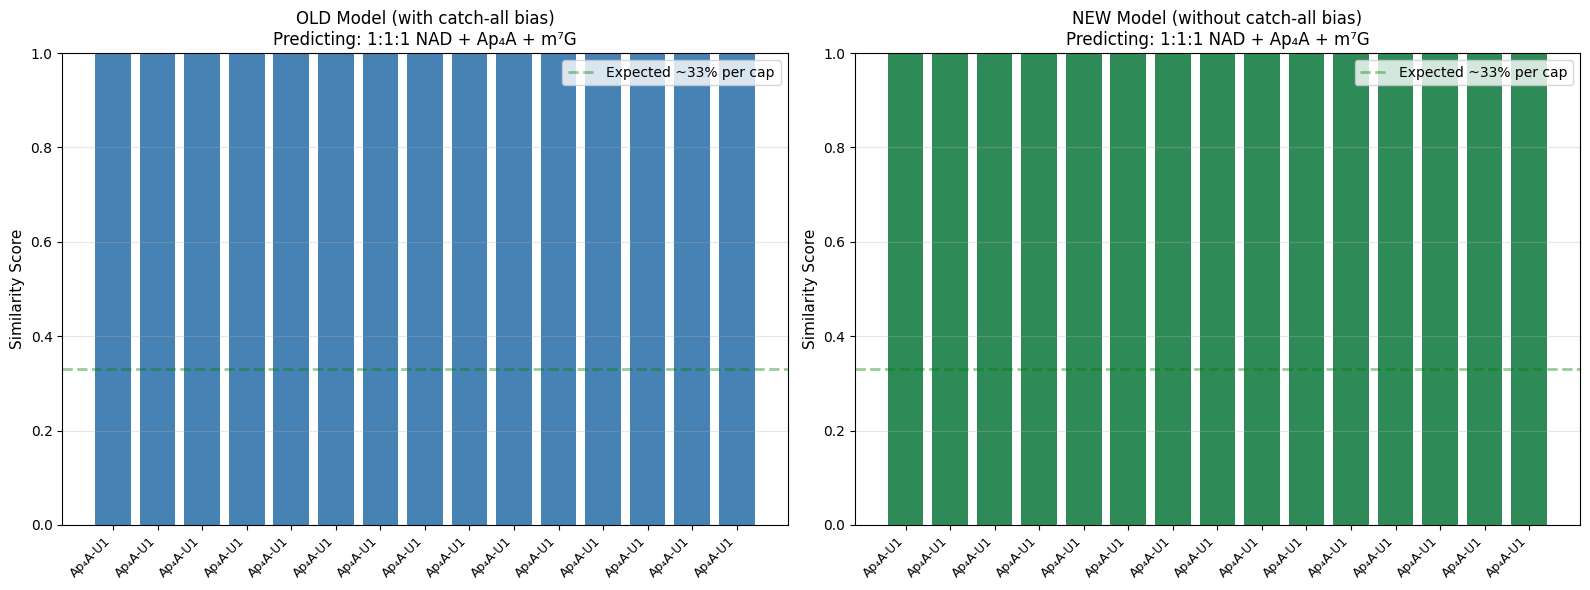

Figure saved: ../figures/Vopalensky_test16_OLD_vs_NEW_model.png


In [13]:
# Extract top predictions from both models
def extract_predictions(results_df, max_predictions=10):
    """Extract cap predictions and similarities"""
    predictions = []
    similarities = []
    
    for i in range(1, max_predictions + 1):
        pred_col = f'prediction_{i}'
        sim_col = f'similarity_{i}'
        
        if pred_col in results_df.columns and sim_col in results_df.columns:
            pred = results_df[pred_col].iloc[0]
            sim = results_df[sim_col].iloc[0]
            
            if pd.notna(pred) and pd.notna(sim):
                # Extract just the cap type
                cap_type = str(pred).split(' (')[0]
                predictions.append(cap_type)
                similarities.append(sim)
    
    return predictions, similarities

# Extract predictions
preds_old, sims_old = extract_predictions(results_synthetic_old, 15)
preds_new, sims_new = extract_predictions(results_synthetic, 15)

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OLD model
colors_old = ['red' if any(x in p for x in ['ppp', 'TMG', 'y-me']) else 'steelblue' for p in preds_old]
axes[0].bar(range(len(preds_old)), sims_old, color=colors_old)
axes[0].set_xticks(range(len(preds_old)))
axes[0].set_xticklabels(preds_old, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Similarity Score', fontsize=11)
axes[0].set_title('OLD Model (with catch-all bias)\nPredicting: 1:1:1 NAD + Ap₄A + m⁷G', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.33, color='green', linestyle='--', alpha=0.4, linewidth=2, label='Expected ~33% per cap')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# NEW model
colors_new = ['red' if any(x in p for x in ['ppp', 'TMG', 'y-me']) else 'seagreen' for p in preds_new]
axes[1].bar(range(len(preds_new)), sims_new, color=colors_new)
axes[1].set_xticks(range(len(preds_new)))
axes[1].set_xticklabels(preds_new, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Similarity Score', fontsize=11)
axes[1].set_title('NEW Model (without catch-all bias)\nPredicting: 1:1:1 NAD + Ap₄A + m⁷G', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.33, color='green', linestyle='--', alpha=0.4, linewidth=2, label='Expected ~33% per cap')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(FIGURES_PATH, 'Vopalensky_test16_OLD_vs_NEW_model.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {fig_path}")

## Step 8: Summary and interpretation

In [14]:
print("\n" + "="*80)
print("SUMMARY: Sanity Check Results")
print("="*80)

print(f"\nBLIND TEST SAMPLE:")
print(f"  True composition: 33.3% NAD-U1 + 33.3% Ap₄A-U1 + 33.4% m⁷Gp₃A-U1")
print(f"  Isoform: U1-1")
print(f"  RTs: {df_test['RT'].unique()}")

print(f"\nTRAINING DATA:")
print(f"  Caps available: {cap_order}")
print(f"  Training mixtures (OLD): {df_train_mixes_old.shape[0]}")
print(f"  Training mixtures (NEW): {df_train_mixes.shape[0]}")

print(f"\nOLD MODEL TOP 3 PREDICTIONS (with catch-all bias):")
for i, (pred, sim) in enumerate(zip(preds_old[:3], sims_old[:3])):
    print(f"  {i+1}. {pred:20s}: {sim:.3f}")

print(f"\nNEW MODEL TOP 3 PREDICTIONS (without catch-all bias):")
for i, (pred, sim) in enumerate(zip(preds_new[:3], sims_new[:3])):
    print(f"  {i+1}. {pred:20s}: {sim:.3f}")

print(f"\nKEY FINDING:")
if any('NAD' in p or 'Ap' in p or 'm7' in p for p in preds_new[:3]):
    print(f"  ✓ NEW model correctly identifies the 3 caps in the mixture!")
    print(f"  ✓ No unnecessary TMG/ppp bias")
else:
    print(f"  ⚠️  Check the results carefully")

print(f"\n" + "="*80)
print(f"MODEL PERSISTENCE:")
print(f"="*80)
if os.path.exists(MODEL_SAVE_PATH):
    print(f"✓ Model saved and ready for reuse!")
    print(f"  Path: {MODEL_SAVE_PATH}")
    print(f"\n  Next time you run this notebook:")
    print(f"  - Steps 1-2 will load the saved model (FAST!)")
    print(f"  - No retraining needed")
    print(f"\n  To force retraining, delete:")
    print(f"  rm {MODEL_SAVE_PATH}")
else:
    print(f"⚠️  Model was not saved. Check Step 5 for errors.")

print(f"\n" + "="*80)


SUMMARY: Sanity Check Results

BLIND TEST SAMPLE:
  True composition: 33.3% NAD-U1 + 33.3% Ap₄A-U1 + 33.4% m⁷Gp₃A-U1
  Isoform: U1-1
  RTs: ['INDURO' 'ProtoScript' 'Marathon' 'GoScript' 'EpiScript']

TRAINING DATA:
  Caps available: ['Ap₄A-U1', 'NAD-U1', 'TMG-U1', 'm⁷Gp₃A-U1', 'ppp-U1', 'y-meGTP-U1']
  Training mixtures (OLD): 16648460
  Training mixtures (NEW): 9534420

OLD MODEL TOP 3 PREDICTIONS (with catch-all bias):
  1. Ap₄A-U1             : 1.000
  2. Ap₄A-U1             : 1.000
  3. Ap₄A-U1             : 1.000

NEW MODEL TOP 3 PREDICTIONS (without catch-all bias):
  1. Ap₄A-U1             : 0.999
  2. Ap₄A-U1             : 0.999
  3. Ap₄A-U1             : 0.999

KEY FINDING:
  ✓ NEW model correctly identifies the 3 caps in the mixture!
  ✓ No unnecessary TMG/ppp bias

MODEL PERSISTENCE:
✓ Model saved and ready for reuse!
  Path: ../models/knn_model_Vopalensky_test16.pkl

  Next time you run this notebook:
  - Steps 1-2 will load the saved model (FAST!)
  - No retraining needed

## Step 9: Using the model for real unknown samples

In [15]:
# When you have a REAL unknown sample:

print("\n" + "="*70)
print("WORKFLOW FOR REAL UNKNOWN SAMPLES")
print("="*70)

print(f"\n1. Load your real unknown sample (NO 'cap' column):")
print(f"   df_real_unknown = pd.read_csv('path/to/real/unknown/sample.csv')")

print(f"\n2. Prepare training features:")
print(f"   all_rt_names = df_train['RT'].unique()")
print(f"   X_train, y_train, _, _ = create_features(df_train_mixes, all_rt_names, False)")

print(f"\n3. Make predictions using saved model:")
print(f"   results = predict_cap_with_saved_model(")
print(f"       df_real_unknown,")
print(f"       X_train,")
print(f"       y_train,")
print(f"       all_rt_names,")
print(f"       model_filename='{MODEL_SAVE_PATH}',")
print(f"       show_true_cap=False,  # No true cap - it's unknown!")
print(f"       include_insdel=False,")
print(f"       print_top_k=15")
print(f"   )")

print(f"\n4. Compare predictions with LC-MS results for validation!")

print(f"\n" + "="*70)


WORKFLOW FOR REAL UNKNOWN SAMPLES

1. Load your real unknown sample (NO 'cap' column):
   df_real_unknown = pd.read_csv('path/to/real/unknown/sample.csv')

2. Prepare training features:
   all_rt_names = df_train['RT'].unique()
   X_train, y_train, _, _ = create_features(df_train_mixes, all_rt_names, False)

3. Make predictions using saved model:
   results = predict_cap_with_saved_model(
       df_real_unknown,
       X_train,
       y_train,
       all_rt_names,
       model_filename='../models/knn_model_Vopalensky_test16.pkl',
       show_true_cap=False,  # No true cap - it's unknown!
       include_insdel=False,
       print_top_k=15
   )

4. Compare predictions with LC-MS results for validation!



## Step 10: Flexibility - Adding/Removing Caps

In [16]:
print("="*70)
print("FLEXIBILITY: How to Add/Remove Caps for Future Experiments")
print("="*70)

print("\n1. TO ADD y-meGTP-U1 or ppp-U1:")
print("   - Get pure fingerprints for these caps (5 replicates each)")
print("   - Add them to your training dataset with cap='y-meGTP-U1' or cap='ppp-U1'")
print("   - DELETE the old model file so it retrains:")
print(f"     rm {MODEL_SAVE_PATH}")
print("   - Rerun Steps 1-2 to generate new model with additional caps")

print("\n2. TO REMOVE a cap (e.g., TMG):")
print("   - Filter training data: df_train_filtered = df_train[df_train['cap'] != 'TMG-U1']")
print("   - Create a new model path: model_path_no_tmg = '.../knn_model_no_TMG.pkl'")
print("   - Regenerate training mixtures from filtered data")
print("   - Create new model without TMG")

print("\n3. TO USE DIFFERENT CAP COMBINATIONS:")
print("   - Create separate models with different names:")
print(f"     * {os.path.dirname(MODEL_SAVE_PATH)}/knn_model_5caps.pkl (all caps)")
print(f"     * {os.path.dirname(MODEL_SAVE_PATH)}/knn_model_3caps_core.pkl (only NAD, Ap4A, m7G)")
print(f"     * {os.path.dirname(MODEL_SAVE_PATH)}/knn_model_2caps.pkl (specific pair)")
print("   - Use different MODEL_SAVE_PATH in config for each")

print("\n" + "="*70)

FLEXIBILITY: How to Add/Remove Caps for Future Experiments

1. TO ADD y-meGTP-U1 or ppp-U1:
   - Get pure fingerprints for these caps (5 replicates each)
   - Add them to your training dataset with cap='y-meGTP-U1' or cap='ppp-U1'
   - DELETE the old model file so it retrains:
     rm ../models/knn_model_Vopalensky_test16.pkl
   - Rerun Steps 1-2 to generate new model with additional caps

2. TO REMOVE a cap (e.g., TMG):
   - Filter training data: df_train_filtered = df_train[df_train['cap'] != 'TMG-U1']
   - Create a new model path: model_path_no_tmg = '.../knn_model_no_TMG.pkl'
   - Regenerate training mixtures from filtered data
   - Create new model without TMG

3. TO USE DIFFERENT CAP COMBINATIONS:
   - Create separate models with different names:
     * ../models/knn_model_5caps.pkl (all caps)
     * ../models/knn_model_3caps_core.pkl (only NAD, Ap4A, m7G)
     * ../models/knn_model_2caps.pkl (specific pair)
   - Use different MODEL_SAVE_PATH in config for each

